In [ ]:
from concurrent.futures import ThreadPoolExecutor

from pathlib import Path

from graph import graph


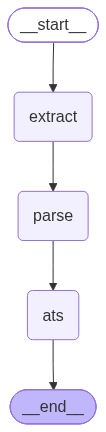

In [ ]:
from IPython.display import display, Image
Image(graph.get_graph().draw_mermaid_png())

In [ ]:


JOB_DESCRIPTION = """
We want a web developer
"""




In [ ]:
def process_resume(path):

    state = {

        "resume_path": str(path),

        "job_description": JOB_DESCRIPTION

    }

    result = graph.invoke(state)

    return result




In [ ]:
BASE_DIR = Path().resolve()
resume_folder = BASE_DIR.parent.parent / "storage" / "resumes"

files = list(resume_folder.glob("*.pdf"))
files += list(resume_folder.glob("*.docx"))



In [ ]:
# Process up to 10 resumes simultaneously
with ThreadPoolExecutor(max_workers=10) as executor:

    results = list(
        executor.map(
            process_resume,
            files
        )
    )



In [ ]:
for r in results:

    print("=" * 60)

    print(r["parsed_resume"])

    print()

    print(r["ats_result"])

id=None name=None cgpa=None university=None projects=[] skills=[] experience=[] certifications=[]

ats_score=0 recommendation='Reject' matched_skills=[] missing_skills=['web development', 'programming languages', 'frameworks'] strengths=[] recommendations=['Gain experience in web development', 'Acquire relevant skills and certifications'] matched_sections=[] missing_requirements=['web development experience', 'programming skills', 'relevant certifications']


In [ ]:
from IPython.display import display, Markdown

for i, r in enumerate(results, 1):
    resume = r["parsed_resume"]
    ats = r["ats_result"]

    display(Markdown(f"# Resume {i}"))
    display(Markdown("---"))

    # Resume Information
    display(Markdown("## 📄 Parsed Resume"))

    print(f"Name        : {resume.name}")
    print(f"University  : {resume.university}")
    print(f"CGPA        : {resume.cgpa}")

    print("\nProjects")
    for p in resume.projects:
        print(f"  • {p}")

    print("\nSkills")
    print(", ".join(resume.skills))

    print("\nExperience")
    for exp in resume.experience:
        print(f"  • {exp}")

    if resume.certifications:
        print("\nCertifications")
        for c in resume.certifications:
            print(f"  • {c}")

    display(Markdown("---"))

    # ATS Result
    display(Markdown("## 🎯 ATS Analysis"))

    print(f"ATS Score      : {ats.ats_score}/100")
    print(f"Recommendation : {ats.recommendation}")

    print("\n✅ Matched Skills")
    print(", ".join(ats.matched_skills) if ats.matched_skills else "None")

    print("\n❌ Missing Skills")
    print(", ".join(ats.missing_skills) if ats.missing_skills else "None")

    print("\n💪 Strengths")
    for s in ats.strengths:
        print(f"  • {s}")

    print("\n📌 Recommendations")
    for rec in ats.recommendations:
        print(f"  • {rec}")

    print("\n✔ Matched Requirements")
    for sec in ats.matched_sections:
        print(f"  • {sec.job_requirement}")
        print(f"    Evidence: {sec.resume_evidence}")

    print("\n⚠ Missing Requirements")
    for req in ats.missing_requirements:
        print(f"  • {req}")

    display(Markdown("---"))

# Resume 1

---

## 📄 Parsed Resume

Name        : None
University  : None
CGPA        : None

Projects

Skills


Experience


---

## 🎯 ATS Analysis

ATS Score      : 0/100
Recommendation : Reject

✅ Matched Skills
None

❌ Missing Skills
web development, programming languages, frameworks

💪 Strengths

📌 Recommendations
  • Gain experience in web development
  • Acquire relevant skills and certifications

✔ Matched Requirements

⚠ Missing Requirements
  • web development experience
  • programming skills
  • relevant certifications


---